# Algotytm przecinania się odcinków na płaszczyźnie

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import random as rnd
import matplotlib.pyplot as plt
import heapq as hq
from sortedcontainers import SortedSet
from bitalg.tests.test4 import Test
from bitalg.visualizer.main import Visualizer

# Przydatne funkcje 

In [2]:
def draw_example_1():
    vis = Visualizer()
    line_segments = ((-0.5, 0.5), (8.5, 3.5),
                     (1, 3), (7, 5),
                     (2, 4), (5, 1),
                     (4.5, 3), (6.5, 6),
                     (0, 5), (5.5, 5.5))

    vis.add_line_segment(line_segments)
    vis.show()
    
def draw_example_2():
    vis = Visualizer()
    line_segments = ((-0.5, 0.5), (8.5, 3.5),
                     (1, 3), (7, 5),
                     (2, 4), (5, 1),
                     (4.5, 3), (6.5, 6),
                     (0, 5), (5.5, 5.5))
    points = [(4, 2),
              (2.5, 3.5),
              (5.5, 4.5)]

    vis.add_line_segment(line_segments)
    vis.add_point(points, color='red')
    vis.show()


### Wprowadzenie
Celem ćwiczenia jest implementacja i zapoznanie się z algorytmem wyznaczającym wszystkie przecięcia się odcinków na płaszczyźnie

### Przykładowy zbiór odcinków przed wyznaczeniem punktów przecięcia

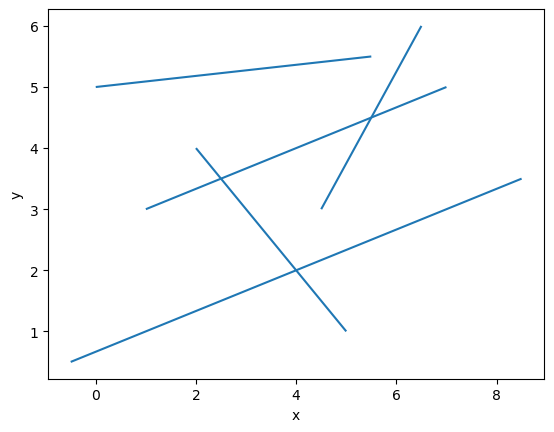

In [4]:
draw_example_1()

### Przykładowy zbiór odcinków po wyznaczenu punktów przecięcia

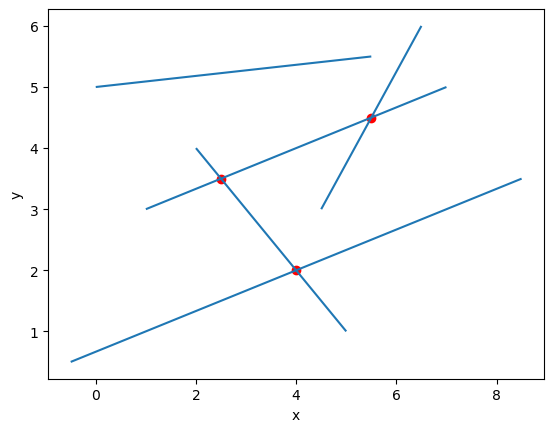

In [5]:
draw_example_2()

# Generowanie losowych odcinków na płaszczyźnie

Uzupełnij funkcję ```generate_uniform_sections```

In [4]:
def generate_uniform_sections(max_x, max_y, n):
    """
    Funkcja generuje odcinki o współrzędnych rzeczywistych w postaci par punktów. 
    Żaden wygenerowany odcinek nie jest odcinkiem pionowym.
    Żadne dwa odcinki nie mają swoich końców o takiej samej współrzędnej x.
    Zakres współrzędnych: x -> (0, max_x), y -> (0, max_y)
    :param max_x: określa maksymalną wartość współrzednej x jaka może zostać wylosowana
    :param max_y: określa maksymalną wartość współrzednej y jaka może zostać wylosowana
    :param n: ilość generowanych odcinków
    :return: tablica odcinków w postaci krotek zawierających parę krotek współrzędnych punktów końcowych odcinków
    np. [((x1, y1), (x2, y2)), ((x3, y3), (x4, y4)),...]
    """
    sections = []
    xs = set()
    
    while len(sections) < n:
        x1 = rnd.uniform(0, max_x)
        if x1 in xs:
            continue
        x2 = rnd.uniform(0, max_x)
        if x2 in xs or x2 == x1:
            continue
        
        xs.add(x1)
        xs.add(x2)
        y1 = rnd.uniform(0, max_y)
        y2 = rnd.uniform(0, max_y)
        sections.append(((x1, y1), (x2, y2)))
        
    return sections
        
        
        

In [5]:
Test().runtest(1, generate_uniform_sections)

Lab 4, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.078s


<span style="color:red">Ćw.</span> Wygeneruj $\large20$ losowych odcinków w przestrzeni 2D o współrzędnych z przedziału $\large x \in \langle 0,1000 \rangle$ oraz $\large y \in \langle 0,1000\rangle$. 

In [6]:
section = generate_uniform_sections(1000, 1000, 20)

Zwizualizuj otrzymane odcinki

[((962.8630534725213, 364.61034211390074), (868.0323011896703, 499.9631897437584)), ((946.7243087918816, 517.5451350177583), (380.9882875377556, 179.83382853388287)), ((629.52177561165, 16.981050364670125), (886.8644467297579, 610.6866702225301)), ((550.3507689992713, 3.245797673545492), (789.1395338506285, 575.6915386822494)), ((359.4577486992965, 964.8015104738824), (970.5261787354395, 916.82467139282)), ((424.21044232933247, 437.770416800776), (767.9828515884516, 939.1823630804511)), ((487.45773143963646, 205.2142147991435), (99.27745919807585, 436.1978057545994)), ((502.9440244397171, 454.2826643480112), (800.0559073115531, 445.842189259862)), ((192.60557823129741, 646.9112637984556), (249.63750966990173, 445.6301825444858)), ((357.88588380474704, 991.35600127124), (432.3080893147975, 924.4962223717004)), ((372.76340440592, 403.2844941904361), (921.8032229361739, 265.51333207291515)), ((816.0636364055246, 813.6633658063107), (34.072136834328305, 919.6493237902766)), ((917.606870138

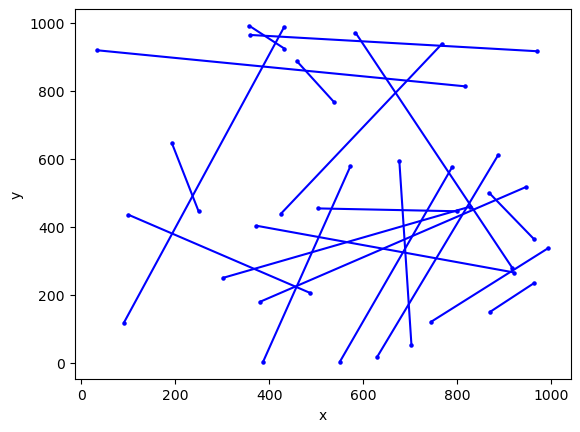

In [7]:
vis = Visualizer()
vis.add_line_segment(section, color="blue")
vis.add_point([section[i // 2][i % 2] for i in range(2 * len(section))], color="blue", s = 5)
vis.show()
print(section)

Uzupełnij funkcję ```add_sections``` #interaktywne dodawanie odcinków przez rysowanie myszką

In [21]:
import matplotlib.pyplot as plt
%matplotlib tk 

class SegmentBuilder:
    def __init__(self):
        self.segments = []
        self.xs_set = set()
        self.active = True
        self.current_points = []

        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        self.fig.canvas.manager.set_window_title("Kreator odcinków")
        self.ax.set_title("Podwójne kliknięcie LPM: dodaj punkt\nPodwójne kliknięcie PPM: zakończ")
        self.ax.set_xlim([0, 2])
        self.ax.set_ylim([0, 2])
        self.ax.set_aspect(1)
        self.ax.grid(True, linestyle='--', alpha=0.6)
        
        self.cid = self.fig.canvas.mpl_connect("button_press_event", self.on_click)

    def draw_point(self, x, y):
        """Rysuje punkt na wykresie."""
        self.ax.scatter(x, y, color="red", zorder=5)
        self.fig.canvas.draw()

    def draw_segment(self, p1, p2):
        """Rysuje odcinek między dwoma punktami."""
        line, = self.ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                             color='blue', linewidth=2.0)
        self.fig.canvas.draw()
        return line

    def add_point(self, event):
        """Logika dodawania punktu (LPM)."""
        x, y = event.xdata, event.ydata
        
        if x in self.xs_set:
            self.original_title = self.ax.get_title()
            self.ax.set_title("BŁĄD: Współrzędne X muszą być unikalne!", color='red')
            self.fig.canvas.draw()
            timer = self.fig.canvas.new_timer(interval=1500)
            timer.add_callback(lambda: (self.ax.set_title(self.original_title, color='black'), self.fig.canvas.draw()))
            timer.start()
            return
        
        self.xs_set.add(x)
        self.current_points.append((x, y))
        self.draw_point(x, y)
        
        if len(self.current_points) == 2:
            self.draw_segment(self.current_points[0], self.current_points[1])
            self.segments.append((self.current_points[0], self.current_points[1]))
            self.current_points = []

    def finish_segments(self):
        """Logika kończenia tworzenia odcinków (PPM)."""
        if len(self.segments) < 2:
            self.ax.set_title("Wymagane co najmniej 2 odcinki!", color='red')
            self.fig.canvas.draw()
            return
        
        self.active = False
        self.ax.set_title("Zakończono. Zamykanie okna...", color='green')
        self.fig.canvas.draw()
        
        plt.pause(1.0)
        plt.close(self.fig)

    def on_click(self, event):
        """Główny handler zdarzeń myszy."""
        if not self.active or not event.dblclick:
            return

        if event.button == 1: # LPM
            if event.xdata is not None and event.ydata is not None:
                self.add_point(event)

        elif event.button == 3: # PPM
            self.finish_segments()

if __name__ == "__main__":
    plt.ioff() 
    
    builder = SegmentBuilder()
    

    
   
    plt.show(block=True)
    
    # Ten kod wykona się dopiero po zamknięciu okna
    print(f"Zebrano {len(builder.segments)} odcinków:")
    for i, seg in enumerate(builder.segments):
        print(f"Odcinek {i+1}: {seg}")

Zebrano 8 odcinków:
Odcinek 1: ((np.float64(0.23593073593073594), np.float64(1.7662337662337664)), (np.float64(1.8290043290043287), np.float64(0.5757575757575759)))
Odcinek 2: ((np.float64(1.9025974025974024), np.float64(0.8095238095238098)), (np.float64(0.19264069264069267), np.float64(0.45021645021645024)))
Odcinek 3: ((np.float64(0.09740259740259738), np.float64(0.865800865800866)), (np.float64(0.2705627705627706), np.float64(0.9826839826839828)))
Odcinek 4: ((np.float64(0.32251082251082247), np.float64(0.9956709956709957)), (np.float64(0.5173160173160174), np.float64(1.0562770562770565)))
Odcinek 5: ((np.float64(0.577922077922078), np.float64(1.0432900432900434)), (np.float64(0.7597402597402596), np.float64(0.9480519480519483)))
Odcinek 6: ((np.float64(0.8246753246753247), np.float64(0.9134199134199135)), (np.float64(1.0151515151515151), np.float64(0.8614718614718615)))
Odcinek 7: ((np.float64(1.0757575757575757), np.float64(0.8484848484848486)), (np.float64(1.2402597402597402), np

In [28]:
%matplotlib inline

In [23]:
%matplotlib tk
segments = builder.segments
vis = Visualizer()
vis.add_line_segment(segments, color="blue")
vis.add_point([segments[i // 2][i % 2] for i in range(2 * len(segments))], color="red")
vis.show()
print(segments)
f = open("sections.txt", "w")
f.write(str(segments))
f.close()

[((np.float64(0.23593073593073594), np.float64(1.7662337662337664)), (np.float64(1.8290043290043287), np.float64(0.5757575757575759))), ((np.float64(1.9025974025974024), np.float64(0.8095238095238098)), (np.float64(0.19264069264069267), np.float64(0.45021645021645024))), ((np.float64(0.09740259740259738), np.float64(0.865800865800866)), (np.float64(0.2705627705627706), np.float64(0.9826839826839828))), ((np.float64(0.32251082251082247), np.float64(0.9956709956709957)), (np.float64(0.5173160173160174), np.float64(1.0562770562770565))), ((np.float64(0.577922077922078), np.float64(1.0432900432900434)), (np.float64(0.7597402597402596), np.float64(0.9480519480519483))), ((np.float64(0.8246753246753247), np.float64(0.9134199134199135)), (np.float64(1.0151515151515151), np.float64(0.8614718614718615))), ((np.float64(1.0757575757575757), np.float64(0.8484848484848486)), (np.float64(1.2402597402597402), np.float64(0.8181818181818183))), ((np.float64(1.3008658008658007), np.float64(0.79220779220

Uzupełnij funkcję ```is_intersection```

In [3]:
A = [((435.2035577598673, 438.4647489822966), (962.13681173909, 935.2278309462748)), ((603.0776523180361, 419.29290572196663), (578.2555526890151, 721.2037580786331)), ((298.5624051210368, 430.6175235887902), (603.6815708365923, 620.4239737532107)), ((132.64485900219825, 495.17972689965427), (71.09098185375618, 435.2515863263673)), ((954.6742663293378, 24.008928042905218), (595.7496292929316, 968.6355774988239)), ((361.91241727187986, 461.12740300442044), (261.04158371705864, 55.13102380826784)), ((255.5955057121385, 829.6069343776317), (834.0979171915653, 75.98988906352699)), ((700.3291538736042, 408.0515612769836), (916.9020052235342, 229.7266242558239)), ((40.589745906642435, 787.9563320758747), (907.8088047614566, 991.8539905255976)), ((212.76460722455758, 792.5824378131078), (244.76710827322324, 135.55387699151433)), ((563.0978693225902, 911.9088457860117), (303.89615509411084, 455.22955012487733)), ((785.9667850356352, 923.5488193307931), (763.3225105261902, 113.05201940304876)), ((101.39147414793604, 220.18337882794492), (43.029372013670184, 512.6662994261796)), ((679.5230065892484, 382.3276369718348), (634.0692490178897, 897.7124839248481)), ((546.9682520943269, 240.71091694004286), (55.31648358080399, 478.46061423648433)), ((846.5585377638935, 778.4274933067603), (395.8662754482424, 598.2891680500258)), ((493.6433695280251, 908.5232083533446), (996.9072364064714, 426.23398418560674)), ((286.36179783356516, 313.10309188853233), (574.7473279357096, 676.3708176624142)), ((831.8961461081271, 651.4804143563049), (368.97543484565807, 235.10760029643484)), ((974.6942739281866, 202.89428499533102), (196.09360383223185, 887.8796489784684))]

B = [((962.8630534725213, 364.61034211390074), (868.0323011896703, 499.9631897437584)), ((946.7243087918816, 517.5451350177583), (380.9882875377556, 179.83382853388287)), ((629.52177561165, 16.981050364670125), (886.8644467297579, 610.6866702225301)), ((550.3507689992713, 3.245797673545492), (789.1395338506285, 575.6915386822494)), ((359.4577486992965, 964.8015104738824), (970.5261787354395, 916.82467139282)), ((424.21044232933247, 437.770416800776), (767.9828515884516, 939.1823630804511)), ((487.45773143963646, 205.2142147991435), (99.27745919807585, 436.1978057545994)), ((502.9440244397171, 454.2826643480112), (800.0559073115531, 445.842189259862)), ((192.60557823129741, 646.9112637984556), (249.63750966990173, 445.6301825444858)), ((357.88588380474704, 991.35600127124), (432.3080893147975, 924.4962223717004)), ((372.76340440592, 403.2844941904361), (921.8032229361739, 265.51333207291515)), ((816.0636364055246, 813.6633658063107), (34.072136834328305, 919.6493237902766)), ((917.6068701387535, 278.41264008082766), (583.3340072118496, 971.9756406447042)), ((870.4269728355736, 150.203144764678), (962.9731831792275, 233.9769451714142)), ((827.5536496579847, 459.53989354741196), (301.00616205510977, 249.62770296659997)), ((458.14703817187996, 888.5486018146484), (538.0819354545465, 766.8419846677855)), ((993.6873927317673, 337.3649331648747), (744.1821258851353, 120.35433427381248)), ((386.7239675076748, 2.4786549865996044), (572.4557640138265, 577.693756626332)), ((431.6042756592532, 988.0145387758785), (90.33147695906352, 117.1226518711389)), ((702.6201987001407, 51.69586611034749), (676.7594005731767, 594.8272710931868))]

C = [((np.float64(0.4437229437229437), np.float64(1.6623376623376624)), (np.float64(1.5909090909090908), np.float64(1.0346320346320348))), ((np.float64(1.2316017316017316), np.float64(0.8571428571428572)), (np.float64(0.20129870129870125), np.float64(0.6190476190476191))), ((np.float64(0.4740259740259741), np.float64(1.12987012987013)), (np.float64(0.9718614718614718), np.float64(1.0735930735930737))), ((np.float64(1.2575757575757576), np.float64(1.7619047619047619)), (np.float64(1.7683982683982682), np.float64(1.2770562770562772))), ((np.float64(1.7597402597402596), np.float64(0.5151515151515151)), (np.float64(1.0497835497835497), np.float64(0.2034632034632035))), ((np.float64(0.725108225108225), np.float64(1.8701298701298703)), (np.float64(1.2792207792207793), np.float64(1.484848484848485))), ((np.float64(0.20995670995670995), np.float64(1.393939393939394)), (np.float64(0.6731601731601731), np.float64(1.29004329004329))), ((np.float64(0.8506493506493507), np.float64(0.5930735930735931)), (np.float64(1.2748917748917747), np.float64(0.3722943722943724))), ((np.float64(1.4696969696969697), np.float64(0.8051948051948052)), (np.float64(1.8290043290043287), np.float64(0.6406926406926408))), ((np.float64(0.6341991341991342), np.float64(0.393939393939394)), (np.float64(0.2532467532467532), np.float64(0.18614718614718623))), ((np.float64(1.603896103896104), np.float64(1.8138528138528138)), (np.float64(1.8982683982683983), np.float64(1.9264069264069263))), ((np.float64(0.16666666666666669), np.float64(0.800865800865801)), (np.float64(0.751082251082251), np.float64(0.9220779220779223)))]

D = [((np.float64(0.23593073593073594), np.float64(1.7662337662337664)), (np.float64(1.8290043290043287), np.float64(0.5757575757575759))), ((np.float64(1.9025974025974024), np.float64(0.8095238095238098)), (np.float64(0.19264069264069267), np.float64(0.45021645021645024))), ((np.float64(0.09740259740259738), np.float64(0.865800865800866)), (np.float64(0.2705627705627706), np.float64(0.9826839826839828))), ((np.float64(0.32251082251082247), np.float64(0.9956709956709957)), (np.float64(0.5173160173160174), np.float64(1.0562770562770565))), ((np.float64(0.577922077922078), np.float64(1.0432900432900434)), (np.float64(0.7597402597402596), np.float64(0.9480519480519483))), ((np.float64(0.8246753246753247), np.float64(0.9134199134199135)), (np.float64(1.0151515151515151), np.float64(0.8614718614718615))), ((np.float64(1.0757575757575757), np.float64(0.8484848484848486)), (np.float64(1.2402597402597402), np.float64(0.8181818181818183))), ((np.float64(1.3008658008658007), np.float64(0.7922077922077924)), (np.float64(1.4696969696969697), np.float64(0.7705627705627707)))]


zbiory = [A, B, C, D]
nazwy = ["A", "B", "C", "D"]



A 20
B 20
C 12
D 8


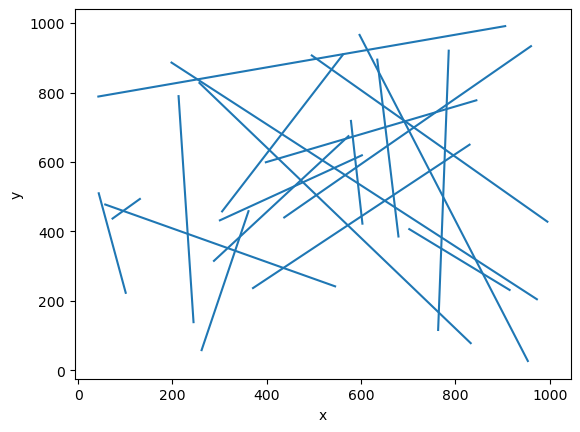

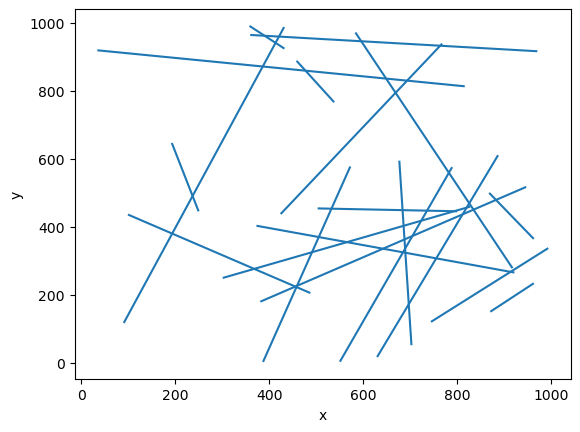

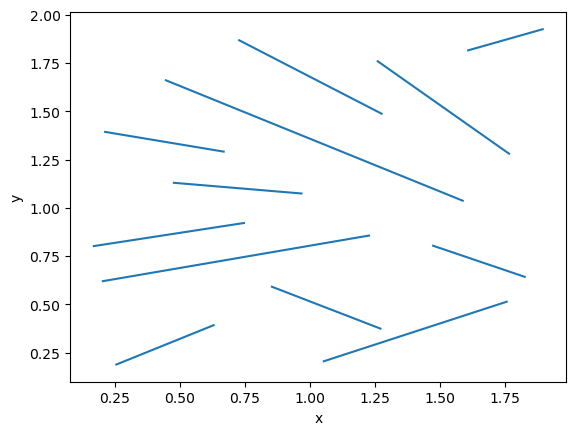

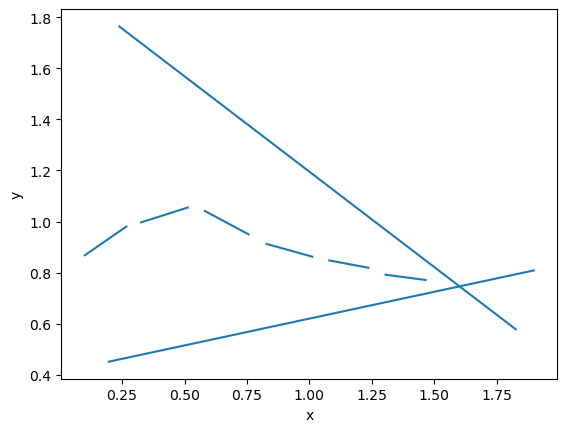

In [4]:
for i in range(len(zbiory)):
    print(nazwy[i], len(zbiory[i]))
    vis = Visualizer()
    vis.add_line_segment(zbiory[i])
    vis.show()
    

In [5]:
eps = 1e-12

In [6]:
class Point:
    def __init__(self, x, y, type = None, segment_idx1 = None, segment_idx2 = None):
        self.x = x
        self.y = y
        self.type = type
        self.segment_idx1 = segment_idx1
        self.segment_idx2 = segment_idx2
        
    def __lt__(self, other):
        if abs(self.x - other.x) > eps:
            return self.x < other.x
        return self.y < other.y
    
    def __eq__(self, other):
        return abs(self.x - other.x) < eps and abs(self.y - other.y) < eps
    
    def __le__(self, other):
        return self < other or self == other
    
    def __hash__(self):
        return hash((self.x, self.y))
    
    def __repr__(self):
        return f"({self.x}, {self.y})"


class Segment:
    #x = None                                    # global variable for all segments indicating where miotla is currently
    def __init__(self, p1, p2, idx):
        self.left = p1
        self.right = p2
        self.left.type = "L"                    # LEFT
        self.right.type = "R"                   # RIGHT
        self.idx = idx
        self.a = (p1.y - p2.y) / (p1.x - p2.x)
        self.b = p1.y - (self.a * p1.x)
        self.sweep = 0 # pozycja miotly
        
    def get_y(self):
        return (self.a * self.sweep) + self.b
    
    def __eq__(self, other):
        return self.idx == other.idx
    
    def __lt__(self, other):
        y1 = self.get_y()
        y2 = other.get_y()
        if abs(y1 - y2) > eps:
            return y1 < y2
        return self.idx < other.idx
    
    def __le__(self, other):
        return self < other or self == other
    
    def __hash__(self):
        return hash((self.left, self.right, self.idx))
    
    def __repr__(self):
        return f"Segment({self.left}, {self.right}, idx: {self.idx})"


In [7]:
def check_intersection(s1, s2):
    # if segments dont exists
    if s1 is None or s2 is None:
        return False
    # paralel segments
    if abs(s1.a - s2.a) < eps:  
        return False
    
    # obliczam potencjalny punkt przeciecia
    x = (s1.b - s2.b) / (s2.a - s1.a)
    y = (s1.a * x) + s1.b
    point = Point(x, y)
    
    # sprwadzam czy punkt przeciecia nalezy do odcinkow
    if max(s1.left, s2.left) <= point \
        and point <= min(s1.right, s2.right): 
        return True
    
    return False


In [9]:
def is_intersection(sections):
    """
    Funkcja sprawdza czy jakakolwiek para podanych odcinków się przecina 
    :param sections: tablica odcinków w postaci krotek krotek współrzędnych punktów końcowych odcinków
    :param eps: epsilon będący dokładnością, z jaką porównujemy liczby zmiennoprzecinkowe
    :return: True / False
    """
    Q = []              # struktura zdarzen - lista
    T = SortedSet()     # struktura stanu - sorted set
    segments = []
    
    for i in range(len(sections)):
        p1, p2 = sections[i]
        left, right = min(p1, p2), max(p1, p2)
        
        point_left = Point(left[0], left[1], "L", i)
        point_right = Point(right[0], right[1], "R", i)
        
        Q.append(point_left)
        Q.append(point_right)
        segments.append(Segment(point_left, point_right, i))
    
    Q.sort()
    
    for event in Q:
        curr_seg = segments[event.segment_idx1]
        if event.type == "L":            # LEFT point
            curr_seg.sweep = event.x
            T.add(curr_seg)              # adding new segment to T
            curr_seg_idx = T.index(curr_seg)
            prev_seg = T[curr_seg_idx-1] if 0 < curr_seg_idx else None
            next_seg = T[curr_seg_idx+1] if curr_seg_idx < len(T) - 1 else None
            if check_intersection(prev_seg, curr_seg):
                return True
            if check_intersection(curr_seg, next_seg):
                return True
            
        elif event.type == "R":          # RIGHT point
            curr_seg_idx = T.index(curr_seg)
            prev_seg = T[curr_seg_idx-1] if 0 < curr_seg_idx else None
            next_seg = T[curr_seg_idx+1] if curr_seg_idx < len(T) - 1 else None
            T.discard(curr_seg)          # removing segemnt from T
            
            if check_intersection(prev_seg, next_seg):
                    return True
                
    return False


In [22]:
Test().runtest(2, is_intersection)

Lab 4, task 2:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.031s


### W jaki sposób zaimplementowałeś struktura stanu (stan miotły) oraz struktura zdarzeń w Twoim programie?

In [ ]:
# struktura stanu to sorted set z biblioteki sortedcontainers 
# pozwala mi ona na wyszukiwanie indeksu danego elementu oraz
# usuwanie elementu z kontenera w zlozonosci O(logn) 
# gdzie n to ilosc elementow w kontenerze, uzywam tego podczas 
# przetwarzania zdarzen

# struktura zdarzen to zwykla lista posortowanych pod wzgledem 
# x punktow (zdarzen)jest to wystarczajace do sprawdzania czy 
# jakiekolwiek przeciecie isnieje poniewaz nie trzeba dodawac 
# do niej punktow przeciecia w trakcie dzialania programu

Uzupełnij funkcję ```is_intersection_with_visualization```

In [8]:
def get_intersection_point(s1, s2):
    """Pomocnicza funkcja do wyliczania punktu przecięcia dla wizualizacji"""
    p1, p2 = s1
    p3, p4 = s2
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    x4, y4 = p4
    
    denom = (y4 - y3) * (x2 - x1) - (x4 - x3) * (y2 - y1)
    if denom == 0: return None # Równoległe
    
    ua = ((x4 - x3) * (y1 - y3) - (y4 - y3) * (x1 - x3)) / denom
    x = x1 + ua * (x2 - x1)
    y = y1 + ua * (y2 - y1)
    return (x, y)

def is_intersection_with_visualization(sections):
    """
    Funkcja sprawdza czy jakakolwiek para podanych odcinków się przecina 
    i wizualizuje proces (miotła, stan T, porównania, punkt przecięcia).
    """
    Q = []              # struktura zdarzen
    T = SortedSet()     # struktura stanu
    segments = []
    
    # Słownik do przechowywania uchwytów wizualizacji aktywnych odcinków (tych w T)
    active_visuals = {} 

    # --- Budowanie wizualizacji początkowej ---
    vis = Visualizer()
    vis.add_line_segment(sections, color="blue") # Wszystkie odcinki na niebiesko (tło)
    vis_points = []
    for section in sections:
        vis_points.append(section[0])
        vis_points.append(section[1])
    vis.add_point(vis_points, color="blue")
        
    # Inicjalizacja zdarzeń
    for i in range(len(sections)):
        p1, p2 = sections[i]
        left, right = min(p1, p2), max(p1, p2)
        
        point_left = Point(left[0], left[1], "L", i)
        point_right = Point(right[0], right[1], "R", i)
        
        Q.append(point_left)
        Q.append(point_right)
        segments.append(Segment(point_left, point_right, i))
    
    Q.sort()
    
    # Określenie granic Y dla rysowania miotły
    min_y = min(p[1] for sec in sections for p in sec) - 0.1
    max_y = max(p[1] for sec in sections for p in sec) + 0.1

    for event in Q:
        curr_seg = segments[event.segment_idx1]
        
        # Wizualizacja miotły (pionowa linia)
        sweep_vis = vis.add_line(((event.x, min_y), (event.x, max_y)), color="red")

        if event.type == "L":            # --- POCZĄTEK ODCINKA ---
            curr_seg.sweep = event.x     # Aktualizacja sweep TYLKO przy dodawaniu
            T.add(curr_seg)
            
            # WIZUALIZACJA: Dodaj do "aktywnych" (pomarańczowy)
            seg_coords = sections[curr_seg.idx]
            active_handle = vis.add_line_segment([seg_coords], color="orange")
            active_visuals[curr_seg.idx] = active_handle

            curr_seg_idx = T.index(curr_seg)
            prev_seg = T[curr_seg_idx-1] if 0 < curr_seg_idx else None
            next_seg = T[curr_seg_idx+1] if curr_seg_idx < len(T) - 1 else None
            
            # Sprawdzenie z poprzednikiem
            if prev_seg is not None:
                # Wizualizacja porównania (zielony)
                vis_check = vis.add_line_segment([sections[curr_seg.idx], sections[prev_seg.idx]], color="green")
                
                if check_intersection(prev_seg, curr_seg):
                    # ZNALEZIONO PRZECIĘCIE -> Rysuj punkt i zwróć
                    pt = get_intersection_point(sections[prev_seg.idx], sections[curr_seg.idx])
                    if pt: vis.add_point([pt], color="red")
                    return True, vis
                
                vis.remove_figure(vis_check) # Usuń zielone, jeśli brak przecięcia
                
            # Sprawdzenie z następnikiem
            if next_seg is not None:
                vis_check = vis.add_line_segment([sections[curr_seg.idx], sections[next_seg.idx]], color="green")
                
                if check_intersection(curr_seg, next_seg):
                    pt = get_intersection_point(sections[curr_seg.idx], sections[next_seg.idx])
                    if pt: vis.add_point([pt], color="red")
                    return True, vis
                
                vis.remove_figure(vis_check)
            
        elif event.type == "R":          # --- KONIEC ODCINKA ---
            # Najpierw pobierz sąsiadów (zanim usuniemy z T)
            curr_seg_idx = T.index(curr_seg)
            prev_seg = T[curr_seg_idx-1] if 0 < curr_seg_idx else None
            next_seg = T[curr_seg_idx+1] if curr_seg_idx < len(T) - 1 else None
            
            T.discard(curr_seg)          # Usuwamy ze struktury stanu
            
            # WIZUALIZACJA: Usuń z "aktywnych" (usuwamy pomarańczowy, wraca niebieski z tła)
            if curr_seg.idx in active_visuals:
                vis.remove_figure(active_visuals[curr_seg.idx])
                del active_visuals[curr_seg.idx]
            
            # Sprawdzenie sąsiadów, którzy stali się nowymi sąsiadami
            if prev_seg is not None and next_seg is not None:
                vis_check = vis.add_line_segment([sections[prev_seg.idx], sections[next_seg.idx]], color="green")
                
                if check_intersection(prev_seg, next_seg):
                    pt = get_intersection_point(sections[prev_seg.idx], sections[next_seg.idx])
                    if pt: vis.add_point([pt], color="red")
                    return True, vis
                
                vis.remove_figure(vis_check)
        
        # Usuwamy miotłę z tego kroku (będzie narysowana nowa w następnym)
        vis.remove_figure(sweep_vis)
                
    return False, vis

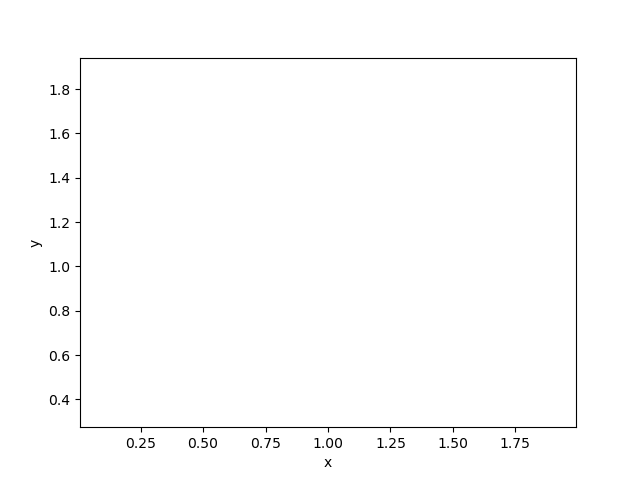

In [14]:
vis.clear()
_, vis = is_intersection_with_visualization(D)
vis.show_gif()

In [9]:
vis.clear()
nazwa = "A"
res, vis = is_intersection_with_visualization(A)
#vis.show()
vis.show_gif()
print(nazwa, res)

A True


B True


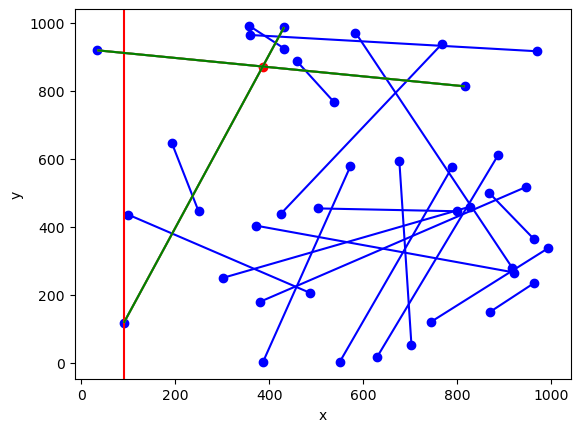

In [18]:
nazwa = "B"
zbior = zbiory[1]
res, vis = is_intersection_with_visualization(zbior)
vis.show()
#vis.show_gif()
print(nazwa, res)

C False


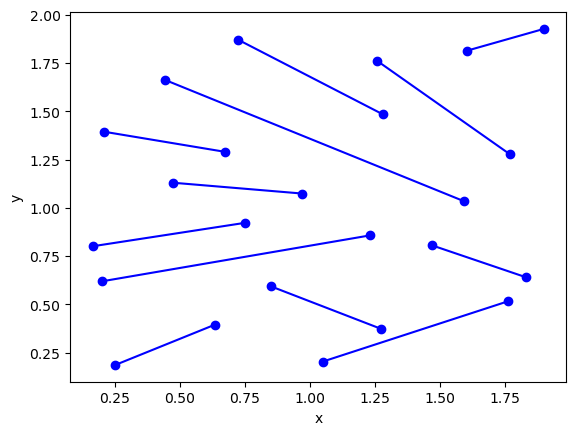

In [14]:
nazwa = "C"
zbior = zbiory[2]
res, vis = is_intersection_with_visualization(zbior)
vis.show()
#vis.show_gif()
print(nazwa, res)

Uzupełnij funkcję ```find_intersections```

In [15]:
def check_intersection1(s1, s2, Q, checked_pairs):
    # if segments dont exists
    if s1 is None or s2 is None:
        return False
    # paralel segments
    if abs(s1.a - s2.a) < eps:  
        return False
    
    # ustawiam pare odcinkow w dobrej kolejnosci
    pair = (min(s1.idx, s2.idx), max(s1.idx, s2.idx))
    if pair in (checked_pairs):
        return False
    checked_pairs.add(pair)
    
    # obliczam potencjalny punkt przeciecia
    x = (s1.b - s2.b) / (s2.a - s1.a)
    y = (s1.a * x) + s1.b
    point = Point(x, y)
    
    # sprawdzam czy punkt nalezy do odcinkow
    if max(s1.left, s2.left) <= point \
        and point <= min(s1.right, s2.right): 
        point.type = "I"        # INTERSECTION
        point.segment_idx1 = s1.idx
        point.segment_idx2 = s2.idx
        hq.heappush(Q, point)
        return True
    
    return False


In [16]:
def find_intersections(sections):
    """
    Funkcja znajduje wszystkie przecięcia zadanych odcinków
    :param sections: tablica odcinków w postaci krotek ktorek współrzędnych punktów końcowych odcinków
    :return: tablica punktów przecięć w postaci trzyelementowych krotek w których pierwszym elementem są współrzędne danego punktu, a drugim i trzecim indeksy prostych z listy wejściowej, które się przecinają w tym punkcie współrzędnych np.:
    [((x1, y1), id1,id2),
    ((x2, y2), id3, id4),
    ...]
    """
    Q = []              # struktura zdarzen - heapq
    T = SortedSet()     # struktura stanu - sorted set
    segments = []
    intersections = []
    checked_pairs = set() # aby unikac sprawdzania tych samych par odcinkow wielokrotnie
    
    for i in range(len(sections)):
        p1, p2 = sections[i]
        left, right = min(p1, p2), max(p1, p2)
        
        point_left = Point(left[0], left[1], "L", i)
        point_right = Point(right[0], right[1], "R", i)
        
        hq.heappush(Q, point_left)
        hq.heappush(Q, point_right)
        segments.append(Segment(point_left, point_right, i))
    
    while len(Q) > 0:
        event = hq.heappop(Q)      # aktualnie przetwarzany punkt
        curr_seg = segments[event.segment_idx1]
        
        if event.type == "L":            # LEFT point
            curr_seg.sweep = event.x     # przesuwam miotle
            T.add(curr_seg)              # adding new segment to T
            #print("add: ", curr_seg.idx)
            curr_seg_idx = T.index(curr_seg)
            prev_seg = T[curr_seg_idx-1] if 0 < curr_seg_idx else None
            next_seg = T[curr_seg_idx+1] if curr_seg_idx < len(T) - 1 else None
            
            # prev with current
            check_intersection1(prev_seg, curr_seg, Q, checked_pairs)
            # current with next
            check_intersection1(curr_seg, next_seg, Q, checked_pairs)
            
        elif event.type == "R":          # RIGHT point
            #Segment.update_x(event.x)  # przesuwam miotle
            curr_seg_idx = T.index(curr_seg)
            prev_seg = T[curr_seg_idx-1] if 0 < curr_seg_idx else None
            next_seg = T[curr_seg_idx+1] if curr_seg_idx < len(T) - 1 else None
            
            check_intersection1(prev_seg, next_seg, Q, checked_pairs)
            T.discard(curr_seg)          # removing segemnt from T
            #print("rm ", curr_seg.idx)

        else:                            # INTERSECT POINT
            s1 = segments[event.segment_idx1]
            s2 = segments[event.segment_idx2]
            #print("int ", s1.idx, s2.idx)
            
            intersections.append(((event.x, event.y), s1.idx+1, s2.idx+1))
            
            # przesuam lekko miotle zeby segemnty zamienily sie miejscami
            T.discard(s1)
            T.discard(s2)
            s1.sweep = event.x + eps
            s2.sweep = event.x + eps
            T.add(s1)
            T.add(s2)
            
            # ustalam wzajemna orientacje segmentow
            idx1, idx2 = min(T.index(s1), T.index(s2)), max(T.index(s1), T.index(s2))
            lower_seg = T[idx1]
            upper_seg = T[idx2]
                
            # sprawdzam potencjalne przecieci z nowymi sasiadami
            if 0 < idx1:
                prev_seg = T[idx1 - 1]
                check_intersection1(prev_seg, lower_seg, Q, checked_pairs)
                
            if idx2 < len(T) - 1:
                next_seg = T[idx2 + 1]
                check_intersection1(upper_seg, next_seg, Q, checked_pairs)
                
            
    return intersections


In [17]:
Test().runtest(3, find_intersections)

Lab 4, task 3:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.031s


In [19]:
for i in range(len(zbiory)):
    print(nazwy[i], len(find_intersections(zbiory[i])))

A 40
B 30
C 0
D 1


Uzupełnij funkcję ```find_intersections_with_visualization```

In [25]:
def find_intersections_with_visualization(sections):
    """
    Funkcja znajduje wszystkie przecięcia zadanych odcinków i dodatkowo zwraca kolejne kroki w wizualizacji 
    """
    Q = []              # struktura zdarzen - heapq
    T = SortedSet()     # struktura stanu - sorted set
    segments = []
    intersections = []
    checked_pairs = set() # aby unikac sprawdzania tych samych par odcinkow wielokrotnie
    
    vis = Visualizer()
    vis.add_line_segment(sections, color="blue")
    vis_points = []
    for section in sections:
        vis_points.append(section[0])
        vis_points.append(section[1])
    vis.add_point(vis_points, color="blue")
    
    active_visuals = {}
    
    # Zabezpieczenie na wypadek pustej listy sections
    if not sections:
        return intersections, vis

    min_y = min(p[1] for sec in sections for p in sec) - 0.1
    max_y = max(p[1] for sec in sections for p in sec) + 0.1

    for i in range(len(sections)):
        p1, p2 = sections[i]
        left, right = min(p1, p2), max(p1, p2)
        
        point_left = Point(left[0], left[1], "L", i)
        point_right = Point(right[0], right[1], "R", i)
        
        hq.heappush(Q, point_left)
        hq.heappush(Q, point_right)
        segments.append(Segment(point_left, point_right, i))
    
    while len(Q) > 0:
        event = hq.heappop(Q)      # aktualnie przetwarzany punkt
        curr_seg = segments[event.segment_idx1]
        
        sweep_vis = vis.add_line(((event.x, min_y), (event.x, max_y)), color="red")
        
        if event.type == "L":            # LEFT point
            curr_seg.sweep = event.x     # przesuwam miotle
            T.add(curr_seg)              # adding new segment to T
            
            active_handle = vis.add_line_segment([sections[curr_seg.idx]], color="orange")
            active_visuals[curr_seg.idx] = active_handle
            
            curr_seg_idx = T.index(curr_seg)
            prev_seg = T[curr_seg_idx-1] if 0 < curr_seg_idx else None
            next_seg = T[curr_seg_idx+1] if curr_seg_idx < len(T) - 1 else None
            
            # prev with current
            if prev_seg is not None:
                # Tworzymy klucz pary (posortowany, aby (a,b) == (b,a))
                pair_key = tuple(sorted((prev_seg.idx, curr_seg.idx)))
                if pair_key not in checked_pairs:
                    vis_check = vis.add_line_segment([sections[prev_seg.idx], sections[curr_seg.idx]], color="green")
                    check_intersection1(prev_seg, curr_seg, Q, checked_pairs)
                    vis.remove_figure(vis_check)
                
            # current with next
            if next_seg is not None:
                pair_key = tuple(sorted((curr_seg.idx, next_seg.idx)))
                if pair_key not in checked_pairs:
                    vis_check = vis.add_line_segment([sections[curr_seg.idx], sections[next_seg.idx]], color="green")
                    check_intersection1(curr_seg, next_seg, Q, checked_pairs)
                    vis.remove_figure(vis_check)
            
        elif event.type == "R":          # RIGHT point
            curr_seg_idx = T.index(curr_seg)
            prev_seg = T[curr_seg_idx-1] if 0 < curr_seg_idx else None
            next_seg = T[curr_seg_idx+1] if curr_seg_idx < len(T) - 1 else None
            
            if prev_seg is not None and next_seg is not None:
                pair_key = tuple(sorted((prev_seg.idx, next_seg.idx)))
                if pair_key not in checked_pairs:
                    vis_check = vis.add_line_segment([sections[prev_seg.idx], sections[next_seg.idx]], color="green")
                    check_intersection1(prev_seg, next_seg, Q, checked_pairs)
                    vis.remove_figure(vis_check)
            
            T.discard(curr_seg)          # removing segemnt from T
            
            if curr_seg.idx in active_visuals:
                vis.remove_figure(active_visuals[curr_seg.idx])
                del active_visuals[curr_seg.idx]

        else:                            # INTERSECT POINT
            s1 = segments[event.segment_idx1]
            s2 = segments[event.segment_idx2]
            
            vis.add_point([(event.x, event.y)], color="red")
            
            intersections.append(((event.x, event.y), s1.idx+1, s2.idx+1))
            
            # przesuam lekko miotle zeby segemnty zamienily sie miejscami
            T.discard(s1)
            T.discard(s2)
            s1.sweep = event.x + 1e-9
            s2.sweep = event.x + 1e-9
            T.add(s1)
            T.add(s2)
            
            # ustalam wzajemna orientacje segmentow
            idx1, idx2 = min(T.index(s1), T.index(s2)), max(T.index(s1), T.index(s2))
            lower_seg = T[idx1]
            upper_seg = T[idx2]
                
            # sprawdzam potencjalne przecieci z nowymi sasiadami
            if 0 < idx1:
                prev_seg = T[idx1 - 1]
                pair_key = tuple(sorted((prev_seg.idx, lower_seg.idx)))
                if pair_key not in checked_pairs:
                    vis_check = vis.add_line_segment([sections[prev_seg.idx], sections[lower_seg.idx]], color="green")
                    check_intersection1(prev_seg, lower_seg, Q, checked_pairs)
                    vis.remove_figure(vis_check)
                
            if idx2 < len(T) - 1:
                next_seg = T[idx2 + 1]
                pair_key = tuple(sorted((upper_seg.idx, next_seg.idx)))
                if pair_key not in checked_pairs:
                    vis_check = vis.add_line_segment([sections[upper_seg.idx], sections[next_seg.idx]], color="green")
                    check_intersection1(upper_seg, next_seg, Q, checked_pairs)
                    vis.remove_figure(vis_check)
        
        vis.remove_figure(sweep_vis)
            
    return intersections, vis

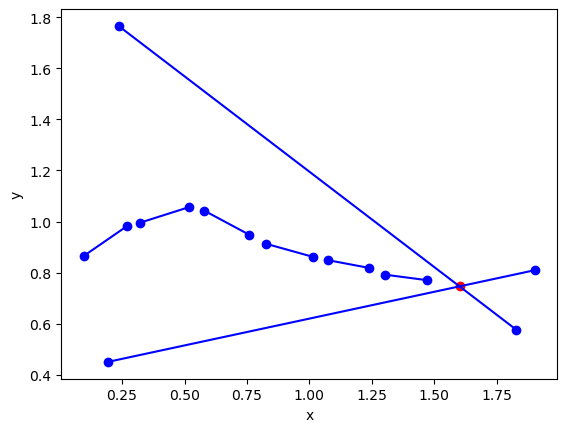

In [34]:
vis.clear()
_, vis = find_intersections_with_visualization(D)
#vis.show_gif()
vis.show()

### Czy konieczne były zmiany w strukturze zdarzeń. Jeśli tak, to jakie? Czy w przypadku obu algorytmów konieczne są takie same struktury zdarzeń?
### Odpowiedź uzasadnij. 

In [ ]:
# zmienilem strukture zdarzen z listy na kolejekie priorytetowa heapq
# w przypadku znajdywania wszystkich punktow przeciec sama lista jest zbut wolna
# poniewaz trzeba do niej dodawac w odpowiednim miejscu nowo powstale zdarzenia
# jakimi sa punkty przeciecia, dzieki uzycu heapq robie to w zlozonosci O(logn)
# gdzie n to liczka elementow na kolejce

### Jak obsługiwane są zdarzenia początku odcinka, końca odcinka i przecięcia odcinków z uwzględnianiem wybranych struktur danych?

In [ ]:
# list
# obsluguje tylko poczatek i koniec odcinka, w przypadku 
# natrafienia na przeciecie program sie konczy.
# przechodze po posortowanej liscie punktow z kotrych zbudowane sa odcinki
# - jesli punkt zaczyna nowy odcinek na miotle to sprawdzam czy przecina
# sie z nowymi sasiadmi
# - jesli punkt konczy odcinek to sprawdzam czy jego 
# dotychczasowi sasiedi sie przecinaja

# heapq
# - poczatek i koniec odcinkow obsluguje tak samo jak w przypadku list
# - punkt przeciecia oznacza dla programu przestawienie miejscami w T 
# odcinkow ktore sie przecinaja oraz sprawdzenie czy przetna sie z nowymi
# sasiadmi w T


### Samemu zaprojektuj test, który uwzględnia taki układ odcinków, przy którym pewne przecięcia będą wykrywane więcej niż jeden raz

In [ ]:
# testing_sections = ???

In [ ]:
### Czy Twój program uwzględnia powyższy przypadek? Jeśli tak, to jak? 

In [ ]:
# moj program rozwiazuje problem przetwarzania tej samej pary 
# odcinow wiecej niz jeden raz poprzez uzycie set checked_pairs
# do ktorego dodaje kazda sprawdzana pare odcinkow
# oraz zawsze przed sprawdzeniem przecinania
# sprawdzam czy ta para juz nie znalazla sie w checked_pairs wczesniej

### Zadanie dodatkowe
Zaimplementuj inną strukturę stanu. Opisz ją w sprawozdaniu. Porównaj efektywność algorytmu dla obu struktur robiąc testy na odpowiednio dużych zestawach odcinków.